<a href="https://colab.research.google.com/github/nepslor/teaching/blob/main/CAS_BDML/L1_bounty_viz_solutions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Bounty Data Visualization Solutions
Is there something interesting in the data? Let's find out!

In [1]:
import pandas as pd
df = pd.read_pickle('https://github.com/nepslor/teaching/raw/refs/heads/main/CAS_BDML/bounty_data.pk')

In [2]:
df

,x,y
2024-01-01 00:00:00,NaN,NaN
2024-01-01 01:00:00,-395.04,-51.04
2024-01-01 02:00:00,NaN,NaN
2024-01-01 03:00:00,NaN,NaN
2024-01-01 04:00:00,NaN,NaN
...,...,...
2027-07-19 05:00:00,NaN,NaN
2027-07-19 06:00:00,-1021.74,-671.74
2027-07-19 07:00:00,-1020.76,-671.76
2027-07-19 08:00:00,NaN,NaN


### Line plot
We already saw that there are some NaNs, let's now try to see how a lineplot of the timeseries looks like.


<Axes: >

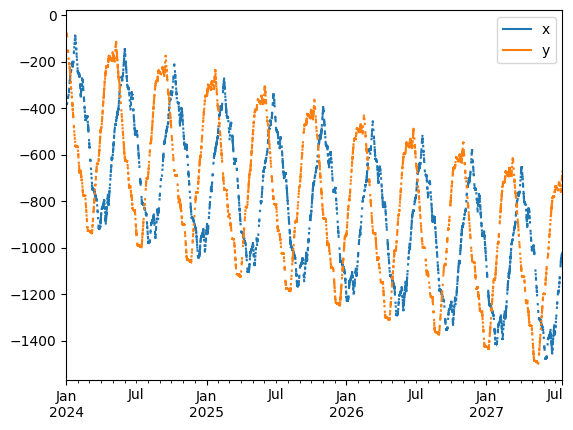

In [3]:
df.plot()

### Scatter plot
The timeseries seem to have a very strong downward trend, which we could try to remove later. But before doing that, let's try to see if there are any interesting patterns in the data by scattering the two variables against each other.

<Axes: xlabel='x', ylabel='y'>

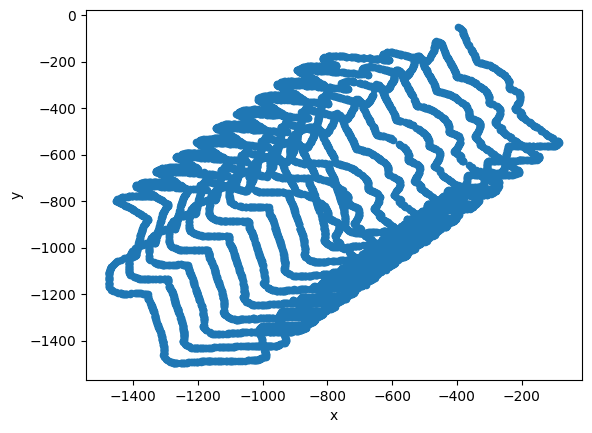

In [4]:
df.plot.scatter(x=0, y=1)

there seem to some circular patterns, but is still not clear. Let's try to retrieve the underlying pattern by removing the smaller cycles pattern. Let's try to do this studying the autocorrelation of the data.
### ACF plot
The autocorrelation function (ACF) can help us identify the presence of cycles in the data. Let's compute the ACF for one of the series and plot it. Before using the ACF, we need to handle the NaN values. We can do this by interpolating the missing values using linear interpolation and then backfilling any remaining NaNs.

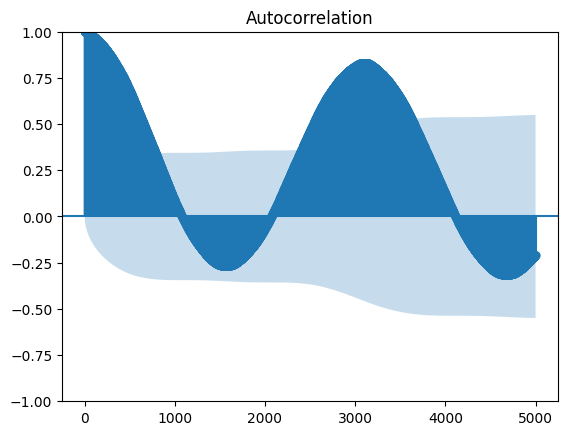

In [5]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
df_interp = df.interpolate('linear').bfill() # drop NaNs for ACF computation
plot_acf(df_interp['x'], lags=5000);

the first local peak is around lag 3000, which suggests that there might be a cycle of approximately 3000 time steps in the data. Let's try to remove this cycle by subtracting a rolling mean with a window of 3000 from the original data using the pandas' `rolling` function.

Text(0.5, 1.0, 'Scatter plot of cycle-removed data')

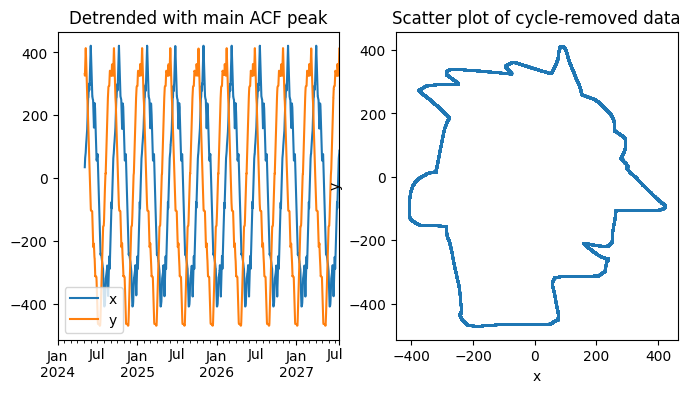

In [6]:
df_dtr_cycle = df_interp - df_interp.rolling(window=3000).mean()
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
df_dtr_cycle.plot(ax=ax[0])
df_dtr_cycle.plot.scatter(x='x', y='y', s=1, ax=ax[1])
ax[0].set_title('Detrended with main ACF peak')
ax[1].set_title('Scatter plot of cycle-removed data')

# Bonus - Linear regression
A similar detrending can be achieved by fitting a linear regression to the data and then removing the fitted values from the original data. This is equivalent to fitting a line to the data and then looking at the residuals, which represent the deviations from the fitted line. Let's try this approach as well.

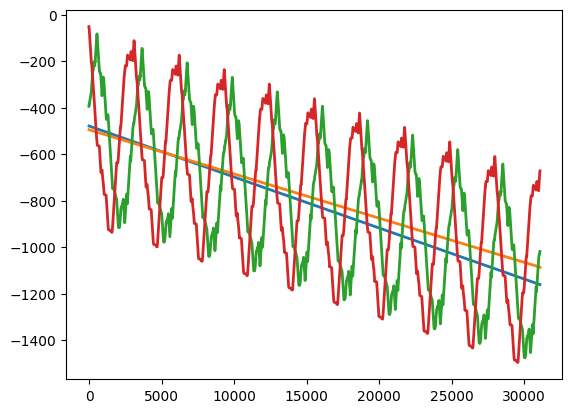

In [7]:
import numpy as np
import matplotlib.pyplot as plt
t = np.arange(len(df_interp))
Y = df_interp.to_numpy()
X = np.column_stack([np.ones_like(t), t]) # [1, t]

# fit all columns at once: Y ~ beta0 + beta1*tY = df_i.to_numpy()
B, *_ = np.linalg.lstsq(X, Y, rcond=None) # shape: (2, n_series)

# fitted values on original scaleY_hat = X @ Bplt.plot(Y, alpha=0.5)
Y_hat = X @ B
plt.plot(Y_hat, linewidth=2)
plt.plot(df_interp.to_numpy(), linewidth=2)
plt.show()

<Axes: xlabel='x', ylabel='y'>

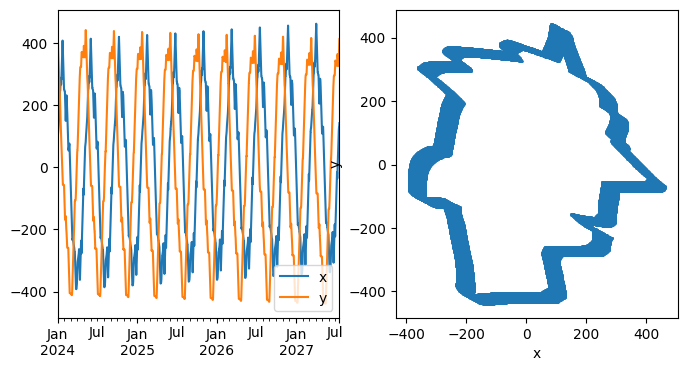

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
(df_interp - Y_hat).plot(ax=ax[0])
(df_interp - Y_hat).plot.scatter(x='x', y='y', s=1, ax=ax[1])
